<a href="https://colab.research.google.com/github/Satish1895/6thSem-ML-Lab/blob/main/1BM23CS306_Lab_4_Logistic_Regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("HR_comma_sep.csv")
df.rename(columns={'left': 'retention'}, inplace=True)

print(df.head())
print(df['retention'].value_counts())
print(df.corr(numeric_only=True))

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  retention  promotion_last_5years  \
0                   3              0          1                      0   
1                   6              0          1                      0   
2                   4              0          1                      0   
3                   5              0          1                      0   
4                   3              0          1                      0   

  Department  salary  
0      sales     low  
1      sales  medium  
2    

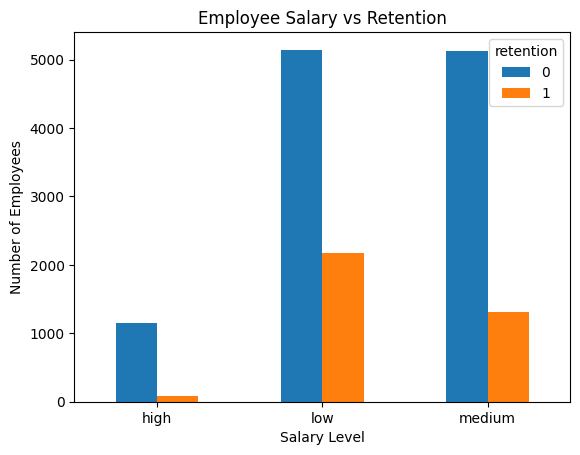

In [ ]:
salary_retention = pd.crosstab(df['salary'], df['retention'])
salary_retention.plot(kind='bar')
plt.title("Employee Salary vs Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.show()

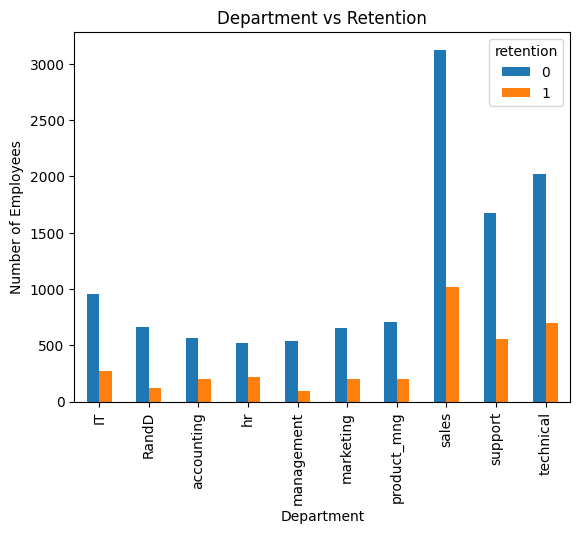

In [ ]:
dept_retention = pd.crosstab(df['Department'], df['retention'])
dept_retention.plot(kind='bar')
plt.title("Department vs Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, columns=['salary', 'Department'], drop_first=True)

X = df_encoded.drop('retention', axis=1)
y = df_encoded['retention']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Confusion Matrix:",confusion_matrix(y_test, y_pred))

Model Accuracy: 0.7855555555555556
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      3428
           1       0.59      0.34      0.43      1072

    accuracy                           0.79      4500
   macro avg       0.70      0.63      0.65      4500
weighted avg       0.76      0.79      0.76      4500

Confusion Matrix: [[3174  254]
 [ 711  361]]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("zoo-data.csv")
class_df = pd.read_csv("zoo-class-type.csv")

df = df.drop(columns=["animal_name"])

In [ ]:
X = df.drop("class_type", axis=1)
y = df["class_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.9354838709677419


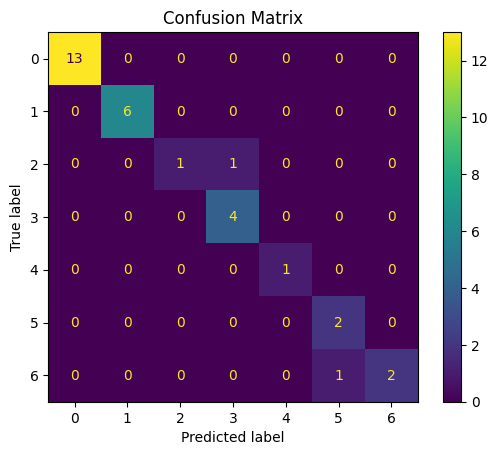

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()